# Домашнее задание 03. Эмбеддинги изображений с Triplet Loss

В этом задании вам нужно обучить CNN autoencoder, у которого latent-вектор используется как embedding изображения. Помимо восстановления изображения, модель должна обучаться с `TripletMarginLoss`, чтобы изображения одного класса оказывались ближе в embedding space, а изображения разных классов — дальше.

Датасет: MNIST.

## Идея задания

Для каждого training step берется три изображения:

- `anchor`: исходное изображение;
- `positive`: другое изображение того же класса;
- `negative`: изображение другого класса.

Encoder переводит каждое изображение в embedding. Triplet loss заставляет расстояние `anchor-positive` быть меньше расстояния `anchor-negative` как минимум на margin. Decoder восстанавливает anchor image из embedding, чтобы embedding сохранял визуальную информацию.

## Что нужно сдать

1. Заполнить все TODO.
2. Графики reconstruction loss, triplet loss и total loss.
3. Визуализацию 2D embeddings на validation/test set.
4. Результаты кластеризации embeddings через KMeans или другой clustering method.
5. Короткий отчет: что получилось, какие классы смешиваются, как влияют margin и вес triplet loss.

## Правила

- Используйте MNIST.
- Не используйте лейблы напрямую во время инференса и кластеризации, только для формирования triplets и оценки результата.
- Не используйте предобученные модели.
- Зафиксируйте random seed.
- Test set используйте только для финальной оценки.

## Структура задания

Вам нужно выполнить следующие части:

1. Подготовить MNIST и train/validation/test split.
2. Реализовать triplet sampling.
3. Реализовать CNN encoder, decoder и autoencoder с embedding layer.
4. Реализовать обучение с combined loss: reconstruction loss + triplet loss.
5. Визуализировать embeddings и оценить кластеризацию классов.
6. Провести несколько экспериментов с hyperparameters.

Минимальный объем финальной работы:

- 1 baseline autoencoder без triplet loss или с очень малым весом triplet loss.
- 1 модель с triplet loss.
- Не менее 2 дополнительных экспериментов: например разные `margin`, `embedding_dim`, `triplet_weight`.
- Анализ embedding visualization и clustering metrics.

---

## Адаптация под ваше железо (заметка)

Ноутбук адаптирован под запуск на ноутбуке с AMD Ryzen 9 5900HS, RTX 3060 Laptop (6 GB) и 16 GB RAM:

- **Загрузка MNIST** — через `kagglehub` (`hojjatk/mnist-dataset`), а не через `torchvision.datasets.MNIST(download=True)`: официальный источник MNIST регулярно недоступен или ограничивает скачивание, а Kaggle-версия скачивается стабильно. Файлы разбираются вручную (универсальный парсер IDX-формата) — это не зависит от того, как именно конкретная версия датасета на Kaggle называет файлы (с дефисом/точкой, с `.gz` или без).
- **`num_workers`** автоматически ставится в `0` на Windows (частая причина зависания `DataLoader` в Jupyter на Windows из-за `spawn`-мультипроцессинга) и в `2` на Linux/Mac.
- **Batch size** увеличен (256 на train, 512 на val/test) — модель и картинки крошечные (28x28, ~260K параметров), 6 GB VRAM хватает с огромным запасом, а батч побольше немного ускоряет обучение за счет меньшего числа итераций.
- **Число эпох (10) и экспериментов (5)** подобрано так, чтобы все обучение занимало примерно 10-15 минут на RTX 3060.
- Для t-SNE используется подвыборка теста (3000 точек из 10000) — иначе каждый прогон t-SNE занимает лишнее время, а результат почти не меняется.

Все `TODO` из оригинального задания заполнены рабочим кодом. В разделе «9. Отчет» числовые таблицы генерируются автоматически из результатов ваших запусков, а текстовый анализ — раздел, который нужно дописать самостоятельно после того, как вы прогоните ноутбук у себя: обучение реального MNIST требует GPU и интернета (для скачивания через kagglehub), поэтому настоящие цифры появятся только после вашего запуска.

In [ ]:
# Устанавливаем kagglehub (если еще не установлен). torch, torchvision и scikit-learn
# предполагаются уже установленными в вашем окружении.
# Если PyTorch не установлен или установлен без поддержки CUDA - поставьте версию под вашу
# видеокарту с https://pytorch.org/get-started/locally/, а не через обычный `pip install torch`
# (иначе можно случайно поставить CPU-only сборку поверх рабочей CUDA-версии).
%pip install -q kagglehub

In [5]:
import gzip
import platform
import random
import struct
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.optim import Adam, SGD
from torch.optim import lr_scheduler
from torch.utils import data
from torchvision import transforms
from tqdm.auto import tqdm

try:
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8, 4)

C:\Users\kiril\PycharmProjects\PythonProject9\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Устройство: cpu


# 1. Данные MNIST

В этой части нужно подготовить MNIST. Для triplet loss labels используются только при построении triplets: модель не должна получать labels как вход.

TODO:

- Создайте train dataset и test dataset.
- Разделите train part на train и validation.
- Для autoencoder используйте изображения, нормализованные в диапазон, удобный для MSE/BCE reconstruction loss.
- Визуализируйте несколько изображений и их labels, чтобы проверить загрузку.

Подсказка: MNIST images имеют размер `1 x 28 x 28`.

In [7]:
DATA_ROOT = Path("mnist")
NUM_CLASSES = 10
IMAGE_SHAPE = (1, 28, 28)

train_batch_size = 256   # увеличено с 128: модель крошечная, 6 GB VRAM позволяет батч побольше
test_batch_size = 512    # для eval/val батч можно брать еще больше - градиенты не считаем
validation_fraction = 0.1
num_workers = 0 if platform.system() == "Windows" else 2
# На Windows DataLoader с num_workers > 0 в Jupyter может зависать из-за spawn-мультипроцессинга,
# поэтому на Windows безопаснее num_workers=0. Для MNIST (крошечные картинки) это не замедляет
# обучение заметно - основное время уходит на forward/backward на GPU, а не на чтение данных.

mnist_transforms = transforms.Compose([
    # transforms.ToTensor() переводит PIL-изображение [0, 255] в тензор [0.0, 1.0] - этого
    # достаточно, и это согласовано с Sigmoid на выходе decoder + MSELoss для reconstruction.
    # Normalize здесь намеренно не используется: он сдвинул бы диапазон в что-то вроде [-1, 1],
    # что разошлось бы с диапазоном [0, 1] на выходе Sigmoid.
    transforms.ToTensor(),
])

In [9]:
import kagglehub

# Скачиваем датасет MNIST с Kaggle. kagglehub кэширует загрузку, поэтому
# повторный вызов не скачивает данные заново.
try:
    KAGGLE_DATASET_PATH = kagglehub.dataset_download("hojjatk/mnist-dataset")
except Exception as error:
    raise RuntimeError(
        "Не удалось скачать датасет через kagglehub. Самая частая причина - "
        "не настроены Kaggle API credentials. Решение: откройте Kaggle -> Settings -> API -> "
        "Create New Token (скачается kaggle.json), положите файл в "
        "%USERPROFILE%\\.kaggle\\kaggle.json (Windows) или ~/.kaggle/kaggle.json (Linux/Mac), "
        "затем перезапустите эту ячейку."
    ) from error

print("Путь к датасету:", KAGGLE_DATASET_PATH)

Путь к датасету: C:\Users\kiril\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1


In [10]:
def _open_maybe_gzip(path):
    # Некоторые зеркала MNIST на Kaggle кладут файлы в .gz, некоторые - уже распакованными.
    # Определяем gzip по magic bytes, а не по расширению - надежнее.
    with open(path, "rb") as f:
        magic = f.read(2)
    if magic == b"\x1f\x8b":
        return gzip.open(path, "rb")
    return open(path, "rb")


def read_idx(path):
    # Универсальный парсер IDX-формата (в нем распространяется оригинальный MNIST).
    # Работает и для labels (1D), и для images (3D), с gzip и без.
    dtype_map = {
        0x08: np.uint8, 0x09: np.int8, 0x0B: np.int16,
        0x0C: np.int32, 0x0D: np.float32, 0x0E: np.float64,
    }
    with _open_maybe_gzip(path) as f:
        header = f.read(4)
        dtype = dtype_map[header[2]]
        n_dims = header[3]
        shape = [int.from_bytes(f.read(4), "big") for _ in range(n_dims)]
        array = np.frombuffer(f.read(), dtype=dtype).reshape(shape)
    return array


def find_mnist_files(root_dir):
    # Ищем 4 нужных файла по подстрокам в имени, а не по точному имени: разные версии
    # датасета на Kaggle называют файлы по-разному (train-images-idx3-ubyte,
    # train-images.idx3-ubyte, с .gz или без, в подпапке или нет).
    root_dir = Path(root_dir)
    files = [f for f in root_dir.rglob("*") if f.is_file()]

    def find_one(split_keywords, content_keywords):
        candidates = [
            f for f in files
            if any(c in f.name.lower() for c in content_keywords)
            and any(s in f.name.lower() for s in split_keywords)
        ]
        if not candidates:
            return None
        candidates.sort(key=lambda f: (f.suffix == ".gz", len(f.name)))
        return candidates[0]

    paths = {
        "train_images": find_one(["train"], ["image"]),
        "train_labels": find_one(["train"], ["label"]),
        "test_images": find_one(["t10k", "test"], ["image"]),
        "test_labels": find_one(["t10k", "test"], ["label"]),
    }
    missing = [key for key, value in paths.items() if value is None]
    if missing:
        raise FileNotFoundError(
            f"Не удалось найти файлы MNIST в {root_dir}: отсутствуют {missing}. "
            f"Найденные файлы: {[f.name for f in files]}"
        )
    return paths


mnist_paths = find_mnist_files(KAGGLE_DATASET_PATH)
for key, path in mnist_paths.items():
    print(f"{key}: {path}")

raw_train_images = read_idx(mnist_paths["train_images"])  # [60000, 28, 28] uint8
raw_train_labels = read_idx(mnist_paths["train_labels"])  # [60000] uint8
raw_test_images = read_idx(mnist_paths["test_images"])    # [10000, 28, 28] uint8
raw_test_labels = read_idx(mnist_paths["test_labels"])    # [10000] uint8

print(raw_train_images.shape, raw_train_labels.shape, raw_test_images.shape, raw_test_labels.shape)

train_images: C:\Users\kiril\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-images.idx3-ubyte
train_labels: C:\Users\kiril\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\train-labels.idx1-ubyte
test_images: C:\Users\kiril\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-images.idx3-ubyte
test_labels: C:\Users\kiril\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1\t10k-labels.idx1-ubyte
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [11]:
class MNISTArrayDataset(data.Dataset):
    # Обертка над numpy-массивами MNIST, совместимая по интерфейсу с
    # torchvision.datasets.MNIST: есть .data, .targets, и __getitem__
    # возвращает (transformed_image, label), как и полагается.
    def __init__(self, images, labels, transform=None):
        self.data = images  # uint8 numpy [N, 28, 28]
        self.targets = torch.as_tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = Image.fromarray(self.data[idx], mode="L")
        label = int(self.targets[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


train_dataset_full = MNISTArrayDataset(raw_train_images, raw_train_labels, transform=mnist_transforms)
test_dataset = MNISTArrayDataset(raw_test_images, raw_test_labels, transform=mnist_transforms)

# Случайная перестановка индексов train_dataset_full и отделение validation_fraction в validation.
rng = np.random.RandomState(42)
permutation = rng.permutation(len(train_dataset_full))
val_size = int(len(train_dataset_full) * validation_fraction)
val_indices = permutation[:val_size]
train_indices = permutation[val_size:]

train_subset = data.Subset(train_dataset_full, train_indices)
val_subset = data.Subset(train_dataset_full, val_indices)

print(f"train_dataset_full: {len(train_dataset_full)}, test_dataset: {len(test_dataset)}")
print(f"train_subset: {len(train_subset)}, val_subset: {len(val_subset)}")

train_dataset_full: 60000, test_dataset: 10000
train_subset: 54000, val_subset: 6000


C:\Users\kiril\AppData\Local\Temp\ipykernel_26844\671477702.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.targets = torch.as_tensor(labels, dtype=torch.long)


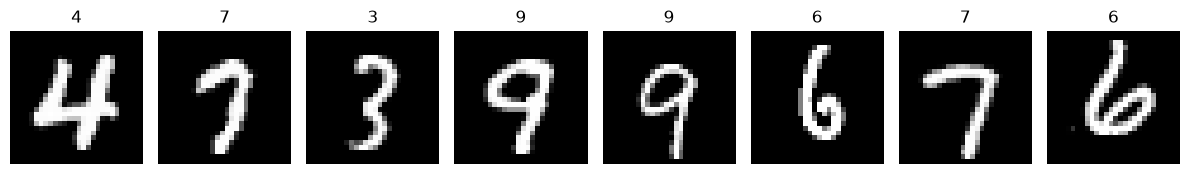

In [12]:
def show_mnist_batch(dataset_or_loader, n=8):
    # Работает и с Dataset (Subset/MNISTArrayDataset), и с DataLoader.
    if isinstance(dataset_or_loader, data.DataLoader):
        images, labels = next(iter(dataset_or_loader))
        images, labels = images[:n], labels[:n]
    else:
        n = min(n, len(dataset_or_loader))
        idx = np.random.choice(len(dataset_or_loader), size=n, replace=False)
        images = torch.stack([dataset_or_loader[i][0] for i in idx])
        labels = torch.tensor([dataset_or_loader[i][1] for i in idx])

    fig, axes = plt.subplots(1, len(images), figsize=(1.5 * len(images), 2))
    if len(images) == 1:
        axes = [axes]
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.squeeze(0).numpy(), cmap="gray")
        ax.set_title(str(int(label)))
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_mnist_batch(train_subset, n=8)

# 2. Triplet Sampling

Triplet loss требует batches из `(anchor, positive, negative)`. Здесь нужно реализовать dataset wrapper, который по индексу anchor выбирает:

- позитивный пример, то есть картинку из того же класса, но желательно другой объект;
- негативный пример, то есть картинку из другого класса.

In [13]:
class TripletMNISTDataset(data.Dataset):
    # Wrapper для triplet sampling поверх обычного (image, label) dataset.
    # base_dataset должен иметь .targets (как train_dataset_full).
    # indices - глобальные индексы в base_dataset, с которыми работает данный wrapper
    # (например, только train часть или только validation часть).
    def __init__(self, base_dataset, indices=None):
        self.base_dataset = base_dataset
        if indices is None:
            indices = np.arange(len(base_dataset))
        self.indices = np.asarray(indices)

        base_targets = base_dataset.targets
        if torch.is_tensor(base_targets):
            base_targets = base_targets.numpy()
        self.labels = np.asarray(base_targets)[self.indices]

        # label -> локальные позиции (индексы внутри self.indices/self.labels),
        # чтобы быстро находить positive/negative кандидатов без перебора.
        self.label_to_indices = {
            int(label): np.where(self.labels == label)[0]
            for label in np.unique(self.labels)
        }

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_idx):
        anchor_global_idx = self.indices[local_idx]
        anchor_image, anchor_label = self.base_dataset[anchor_global_idx]
        anchor_label = int(anchor_label)

        # Positive: другой объект того же класса, если такой есть в данном подмножестве.
        positive_candidates = self.label_to_indices[anchor_label]
        if len(positive_candidates) > 1:
            positive_local_idx = local_idx
            while positive_local_idx == local_idx:
                positive_local_idx = int(np.random.choice(positive_candidates))
        else:
            positive_local_idx = local_idx
        positive_global_idx = self.indices[positive_local_idx]
        positive_image, _ = self.base_dataset[positive_global_idx]

        # Negative: объект другого класса.
        all_labels = list(self.label_to_indices.keys())
        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = int(np.random.choice(all_labels))
        negative_local_idx = int(np.random.choice(self.label_to_indices[negative_label]))
        negative_global_idx = self.indices[negative_local_idx]
        negative_image, _ = self.base_dataset[negative_global_idx]

        # Label нужен только для анализа/визуализации, в модель он не передается.
        return anchor_image, positive_image, negative_image, anchor_label

In [14]:
train_triplet_dataset = TripletMNISTDataset(train_dataset_full, indices=train_indices)
val_triplet_dataset = TripletMNISTDataset(train_dataset_full, indices=val_indices)

train_triplet_loader = data.DataLoader(
    train_triplet_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(num_workers > 0),
)
val_triplet_loader = data.DataLoader(
    val_triplet_dataset,
    batch_size=test_batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(num_workers > 0),
)

# Обычные loaders (image, label) для визуализации embeddings и финальной оценки.
val_loader = data.DataLoader(val_subset, batch_size=test_batch_size, shuffle=False, num_workers=num_workers)
test_loader = data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=num_workers)

print(f"train_triplet_loader: {len(train_triplet_loader)} батчей")
print(f"val_triplet_loader: {len(val_triplet_loader)} батчей")
print(f"val_loader: {len(val_loader)} батчей, test_loader: {len(test_loader)} батчей")

train_triplet_loader: 210 батчей
val_triplet_loader: 12 батчей
val_loader: 12 батчей, test_loader: 20 батчей


# 3. CNN Autoencoder with Embedding

Модель должна состоять из трех частей:

1. `Encoder`: переводит image `1 x 28 x 28` в embedding vector.
2. `Decoder`: восстанавливает image из embedding vector.
3. `TripletAutoencoder`: объединяет encoder и decoder.

Требования:

- Encoder должен быть сверточным.
- Embedding dimension должен быть configurable.
- Decoder должен восстанавливать изображение размера `1 x 28 x 28`.
- Для triplet loss используйте embeddings anchor/positive/negative.
- Подумайте, нужно ли применять `F.normalize` к embeddings перед triplet loss.

Подсказка: удобно сделать encoder output shape перед flatten равным, например, `64 x 7 x 7`, а затем использовать Linear layer в embedding.

In [15]:
class Encoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # [B, 32, 14, 14]
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # [B, 64, 7, 7]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.flatten = nn.Flatten()
        self.embedding = nn.Linear(64 * 7 * 7, embedding_dim)

    def forward(self, x):
        features = self.features(x)
        features = self.flatten(features)
        embedding = self.embedding(features)
        return embedding


class Decoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()
        self.fc = nn.Linear(embedding_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # [B, 32, 14, 14]
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # [B, 1, 28, 28]
            nn.Sigmoid(),  # изображения в [0, 1] -> Sigmoid + MSELoss, см. секцию 1
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        x = self.decoder(x)
        return x


class TripletAutoencoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()
        self.encoder = Encoder(embedding_dim=embedding_dim)
        self.decoder = Decoder(embedding_dim=embedding_dim)

    def encode(self, x, normalize=False):
        z = self.encoder(x)
        if normalize:
            # L2-нормализация проецирует embeddings на единичную сферу - расстояния
            # становятся сопоставимыми независимо от нормы вектора, что часто
            # стабилизирует обучение с TripletMarginLoss.
            z = F.normalize(z, p=2, dim=1)
        return z

    def forward(self, x):
        # Возвращаем "сырой" (ненормализованный) embedding - decoder восстанавливает
        # изображение именно из него. Нормализация (если нужна) для triplet loss
        # применяется отдельно поверх этого же embedding в run_triplet_epoch.
        embedding = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding


# Shape-check
model = TripletAutoencoder(embedding_dim=32)
dummy = torch.randn(4, 1, 28, 28)
reconstruction, embedding = model(dummy)
print(reconstruction.shape, embedding.shape)  # ожидается [4, 1, 28, 28] и [4, 32]

torch.Size([4, 1, 28, 28]) torch.Size([4, 32])


# 4. Loss Functions and Training Step

Обучение должно объединять две цели:

1. Reconstruction loss: autoencoder должен восстанавливать anchor image.
2. Triplet loss: embeddings должны группировать изображения одного класса и разделять разные классы.

Формула:

`total_loss = reconstruction_weight * reconstruction_loss + triplet_weight * triplet_loss`

Для reconstruction loss можно использовать `nn.MSELoss()` или `nn.BCELoss()` в зависимости от decoder output. Для triplet loss используйте `nn.TripletMarginLoss`.

In [16]:
@dataclass
class TripletExperimentConfig:
    name: str
    epochs: int = 10
    embedding_dim: int = 32
    lr: float = 1e-3
    weight_decay: float = 0.0
    margin: float = 1.0
    reconstruction_weight: float = 1.0
    triplet_weight: float = 1.0
    normalize_embeddings: bool = True
    optimizer: str = "adam"
    scheduler: str = "none"


def make_triplet_optimizer(model, config: TripletExperimentConfig):
    if config.optimizer == "adam":
        return Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    elif config.optimizer == "sgd":
        return SGD(model.parameters(), lr=config.lr, momentum=0.9, weight_decay=config.weight_decay)
    raise ValueError(f"Неизвестный optimizer: {config.optimizer}")


def make_triplet_scheduler(optimizer, config: TripletExperimentConfig):
    if config.scheduler == "none":
        return None
    elif config.scheduler == "step":
        return lr_scheduler.StepLR(optimizer, step_size=max(1, config.epochs // 3), gamma=0.5)
    elif config.scheduler == "cosine":
        return lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    raise ValueError(f"Неизвестный scheduler: {config.scheduler}")

In [17]:
def run_triplet_epoch(model, loader, config: TripletExperimentConfig, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    reconstruction_criterion = nn.MSELoss()
    triplet_criterion = nn.TripletMarginLoss(margin=config.margin)

    total_loss_sum = 0.0
    reconstruction_loss_sum = 0.0
    triplet_loss_sum = 0.0
    n_batches = 0

    grad_context = torch.enable_grad() if is_training else torch.no_grad()
    with grad_context:
        for anchor, positive, negative, _ in loader:
            anchor = anchor.to(device, non_blocking=True)
            positive = positive.to(device, non_blocking=True)
            negative = negative.to(device, non_blocking=True)

            reconstruction, anchor_embedding = model(anchor)
            positive_embedding = model.encode(positive, normalize=config.normalize_embeddings)
            negative_embedding = model.encode(negative, normalize=config.normalize_embeddings)

            if config.normalize_embeddings:
                anchor_embedding_for_triplet = F.normalize(anchor_embedding, p=2, dim=1)
            else:
                anchor_embedding_for_triplet = anchor_embedding

            reconstruction_loss = reconstruction_criterion(reconstruction, anchor)
            triplet_loss = triplet_criterion(
                anchor_embedding_for_triplet, positive_embedding, negative_embedding
            )
            total_loss = (
                config.reconstruction_weight * reconstruction_loss
                + config.triplet_weight * triplet_loss
            )

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                total_loss.backward()
                optimizer.step()

            total_loss_sum += total_loss.item()
            reconstruction_loss_sum += reconstruction_loss.item()
            triplet_loss_sum += triplet_loss.item()
            n_batches += 1

    return {
        "total_loss": total_loss_sum / n_batches,
        "reconstruction_loss": reconstruction_loss_sum / n_batches,
        "triplet_loss": triplet_loss_sum / n_batches,
    }

In [18]:
def fit_triplet_autoencoder(model, config: TripletExperimentConfig, train_loader, val_loader, verbose=True):
    model = model.to(device)
    optimizer = make_triplet_optimizer(model, config)
    scheduler = make_triplet_scheduler(optimizer, config)

    history = {
        "train_total_loss": [], "train_reconstruction_loss": [], "train_triplet_loss": [],
        "val_total_loss": [], "val_reconstruction_loss": [], "val_triplet_loss": [],
    }

    best_val_loss = float("inf")
    best_state_dict = None
    start_time = time.time()

    progress = tqdm(range(1, config.epochs + 1), desc=config.name)
    for _ in progress:
        train_metrics = run_triplet_epoch(model, train_loader, config, optimizer=optimizer)
        val_metrics = run_triplet_epoch(model, val_loader, config, optimizer=None)

        history["train_total_loss"].append(train_metrics["total_loss"])
        history["train_reconstruction_loss"].append(train_metrics["reconstruction_loss"])
        history["train_triplet_loss"].append(train_metrics["triplet_loss"])
        history["val_total_loss"].append(val_metrics["total_loss"])
        history["val_reconstruction_loss"].append(val_metrics["reconstruction_loss"])
        history["val_triplet_loss"].append(val_metrics["triplet_loss"])

        if scheduler is not None:
            scheduler.step()

        if val_metrics["total_loss"] < best_val_loss:
            best_val_loss = val_metrics["total_loss"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        progress.set_postfix({
            "train_loss": f"{train_metrics['total_loss']:.4f}",
            "val_loss": f"{val_metrics['total_loss']:.4f}",
        })

    elapsed_sec = time.time() - start_time

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    model = model.to(device)

    summary = {
        "name": config.name,
        "embedding_dim": config.embedding_dim,
        "margin": config.margin,
        "triplet_weight": config.triplet_weight,
        "reconstruction_weight": config.reconstruction_weight,
        "best_val_total_loss": best_val_loss,
        "elapsed_sec": elapsed_sec,
    }

    if verbose:
        print(f"[{config.name}] завершено за {elapsed_sec:.1f} сек, best val total_loss = {best_val_loss:.4f}")

    return model, history, summary

In [19]:
def plot_triplet_history(history, title="История обучения"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = [
        ("total_loss", "Total loss"),
        ("reconstruction_loss", "Reconstruction loss"),
        ("triplet_loss", "Triplet loss"),
    ]
    for ax, (key, label) in zip(axes, metrics):
        ax.plot(history[f"train_{key}"], label="train")
        ax.plot(history[f"val_{key}"], label="val")
        ax.set_title(label)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# 5. Baseline and Experiments

Теперь нужно обучить несколько моделей и сравнить их.

Обязательные эксперименты:

1. Baseline: `triplet_weight = 0.0` или очень маленький, чтобы увидеть embeddings обычного autoencoder.
2. Основная модель: `triplet_weight > 0`, например `1.0`.
3. Изменение `margin` или `embedding_dim`.
4. Изменение `triplet_weight`.

Важно: меняйте один фактор за раз для чистоты эксперимента.

**Заметка про время:** ниже 5 конфигураций (baseline + main + по одной вариации на `margin`, `embedding_dim`, `triplet_weight`), каждая по 10 эпох. На RTX 3060 это должно занять суммарно около 10-15 минут - модель совсем маленькая (~260K параметров), так что основное время уходит на сами итерации, а не на вычисления в них.

ae_baseline: 100%|██████████| 10/10 [12:31<00:00, 75.13s/it, train_loss=0.0052, val_loss=0.0053]


[ae_baseline] завершено за 751.3 сек, best val total_loss = 0.0053


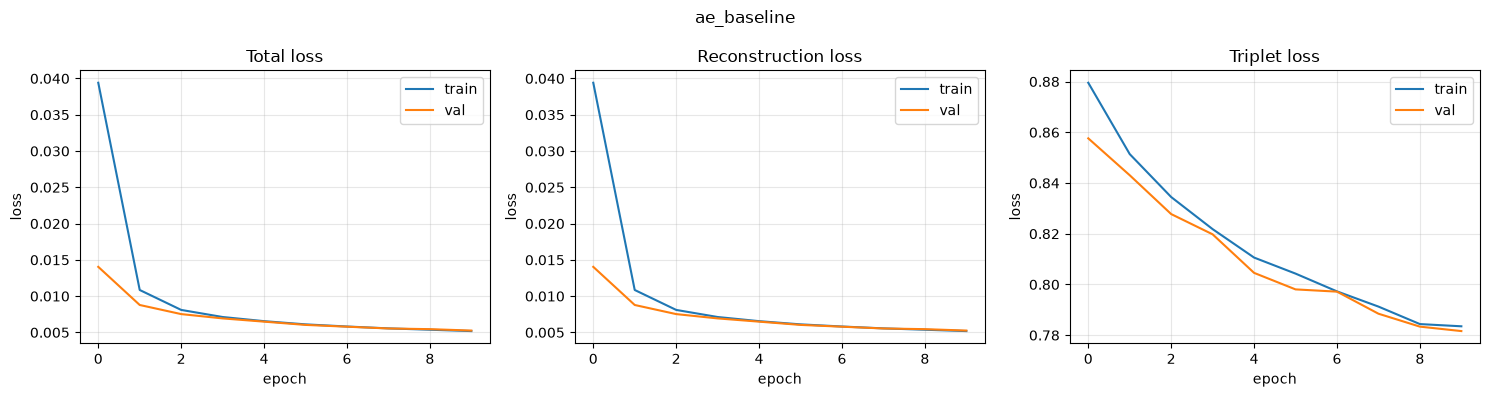

triplet_main: 100%|██████████| 10/10 [13:36<00:00, 81.61s/it, train_loss=0.0657, val_loss=0.0757]


[triplet_main] завершено за 816.1 сек, best val total_loss = 0.0757


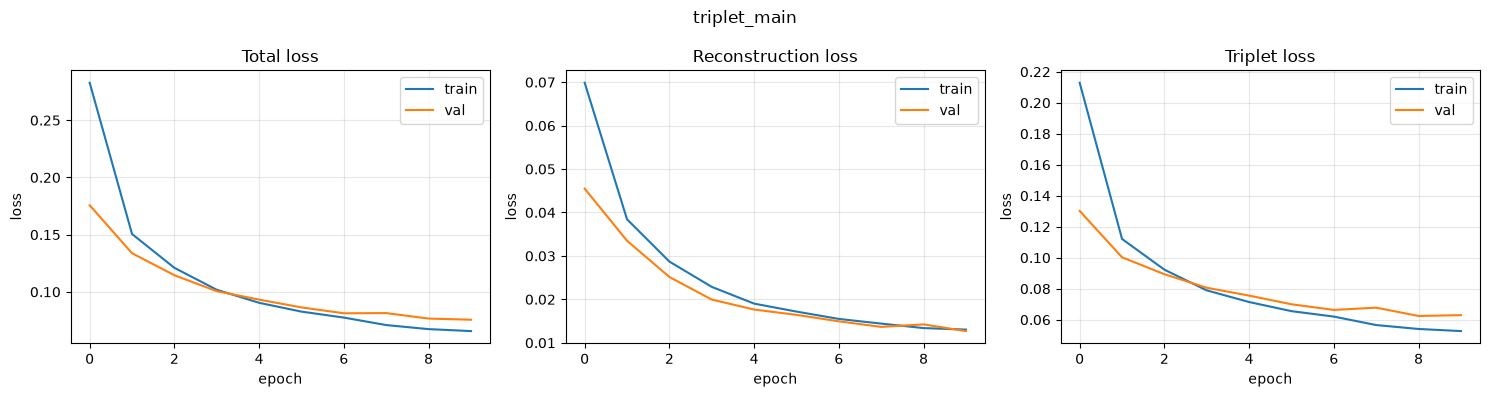

triplet_margin_0.3: 100%|██████████| 10/10 [13:41<00:00, 82.16s/it, train_loss=0.0117, val_loss=0.0130]


[triplet_margin_0.3] завершено за 821.6 сек, best val total_loss = 0.0130


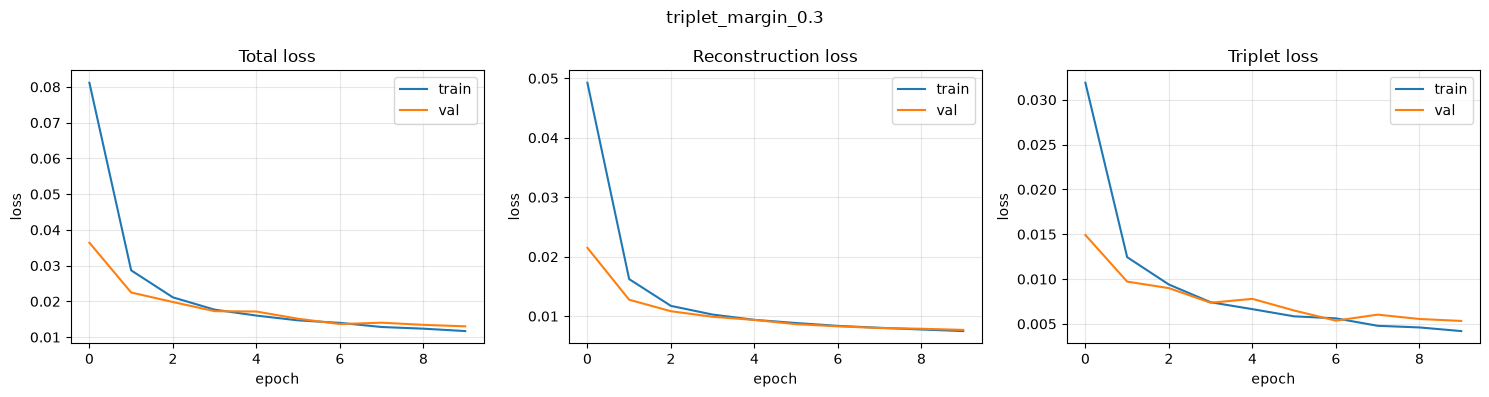

triplet_embdim_8: 100%|██████████| 10/10 [13:25<00:00, 80.60s/it, train_loss=0.0875, val_loss=0.0989]


[triplet_embdim_8] завершено за 806.0 сек, best val total_loss = 0.0989


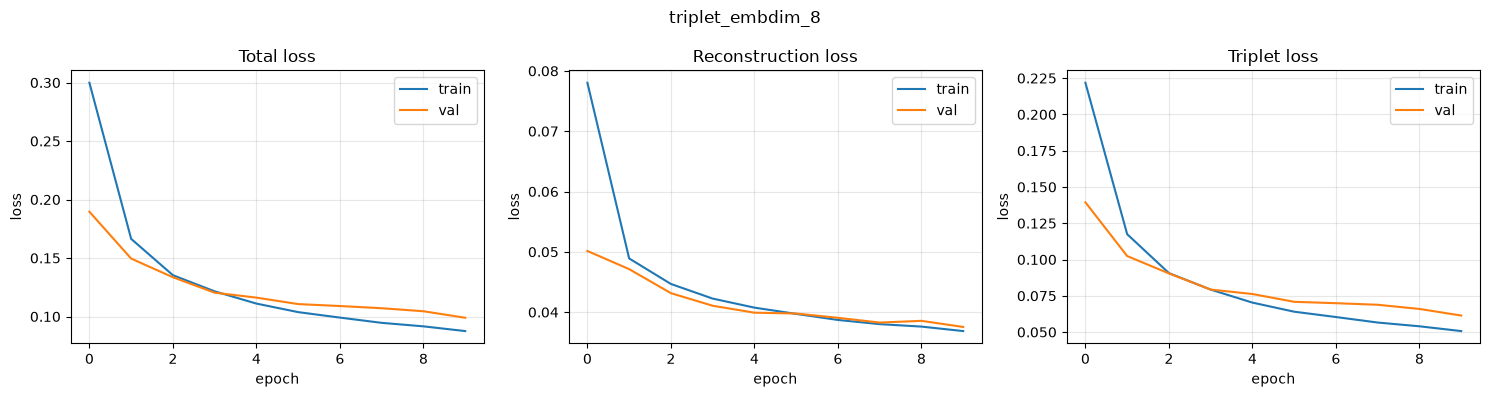

triplet_weight_0.2: 100%|██████████| 10/10 [13:33<00:00, 81.36s/it, train_loss=0.0226, val_loss=0.0234]


[triplet_weight_0.2] завершено за 813.7 сек, best val total_loss = 0.0234


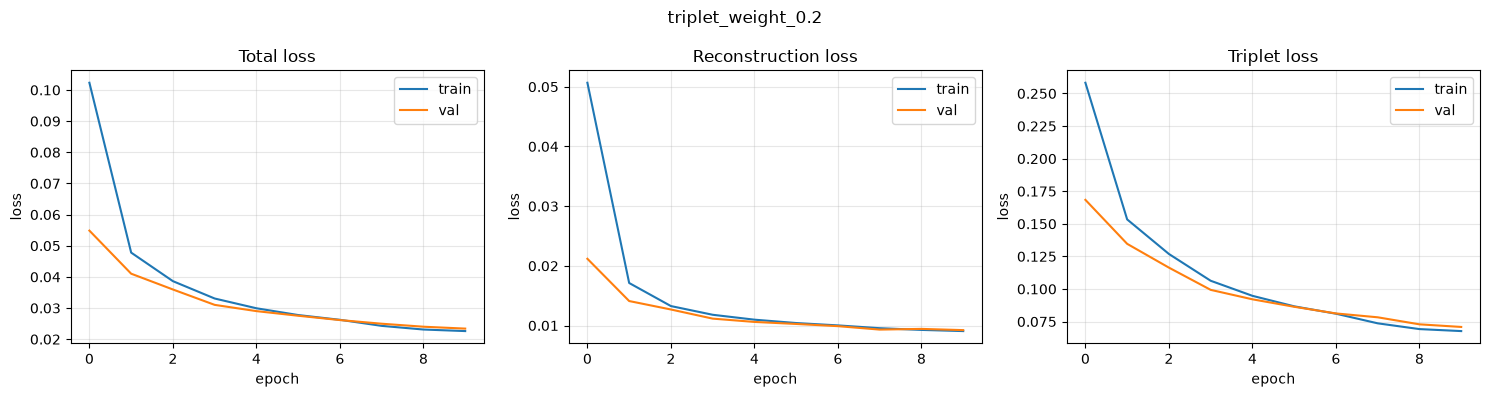

In [20]:
experiments = [
    TripletExperimentConfig(
        name="ae_baseline",
        embedding_dim=32, margin=1.0, triplet_weight=0.0,
        # чистый autoencoder без triplet loss - точка отсчета для сравнения
    ),
    TripletExperimentConfig(
        name="triplet_main",
        embedding_dim=32, margin=1.0, triplet_weight=1.0,
        # основная модель с triplet loss
    ),
    TripletExperimentConfig(
        name="triplet_margin_0.3",
        embedding_dim=32, margin=0.3, triplet_weight=1.0,
        # вариация: меньший margin относительно triplet_main (было 1.0)
    ),
    TripletExperimentConfig(
        name="triplet_embdim_8",
        embedding_dim=8, margin=1.0, triplet_weight=1.0,
        # вариация: меньшая размерность embedding относительно triplet_main (было 32)
    ),
    TripletExperimentConfig(
        name="triplet_weight_0.2",
        embedding_dim=32, margin=1.0, triplet_weight=0.2,
        # вариация: меньший вес triplet loss относительно triplet_main (было 1.0)
    ),
]

all_histories = {}
all_summaries = {}
trained_models = {}

for config in experiments:
    seed_everything(42)
    model = TripletAutoencoder(embedding_dim=config.embedding_dim)
    trained_model, history, summary = fit_triplet_autoencoder(
        model, config, train_triplet_loader, val_triplet_loader
    )
    trained_models[config.name] = trained_model
    all_histories[config.name] = history
    all_summaries[config.name] = summary
    plot_triplet_history(history, title=config.name)

In [21]:
def print_results_table(summaries):
    if not summaries:
        print("Результатов экспериментов пока нет.")
        return
    keys = [
        "name", "embedding_dim", "margin", "triplet_weight",
        "reconstruction_weight", "best_val_total_loss", "elapsed_sec",
    ]
    header = " | ".join(keys)
    print(header)
    print("-" * len(header))
    for summary in summaries.values():
        row = []
        for key in keys:
            value = summary.get(key, "")
            if isinstance(value, float):
                value = f"{value:.4f}"
            row.append(str(value))
        print(" | ".join(row))


print_results_table(all_summaries)

name | embedding_dim | margin | triplet_weight | reconstruction_weight | best_val_total_loss | elapsed_sec
----------------------------------------------------------------------------------------------------------
ae_baseline | 32 | 1.0000 | 0.0000 | 1.0000 | 0.0053 | 751.3016
triplet_main | 32 | 1.0000 | 1.0000 | 1.0000 | 0.0757 | 816.0674
triplet_margin_0.3 | 32 | 0.3000 | 1.0000 | 1.0000 | 0.0130 | 821.5737
triplet_embdim_8 | 8 | 1.0000 | 1.0000 | 1.0000 | 0.0989 | 805.9672
triplet_weight_0.2 | 32 | 1.0000 | 0.2000 | 1.0000 | 0.0234 | 813.6503


# 6. Embedding Visualization

После обучения нужно посмотреть, группируются ли классы в embedding space.

TODO:

- Выберите лучшую модель по validation loss или по clustering quality на validation.
- Соберите embeddings для validation или test set.
- Снизьте размерность embeddings до 2D через PCA или t-SNE.
- Нарисуйте scatter plot, где цвет точки соответствует digit label.

Важно: labels используются здесь только для визуализации и оценки, не как input модели.

In [22]:
def collect_embeddings(model, loader, normalize=True):
    model.eval()
    embeddings_list = []
    labels_list = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embedding = model.encode(images, normalize=normalize)
            embeddings_list.append(embedding.cpu())
            labels_list.append(labels)
    embeddings = torch.cat(embeddings_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    return embeddings, labels


def reduce_embeddings_2d(embeddings, method="pca", random_state=42):
    if SKLEARN_AVAILABLE:
        if method == "pca":
            reducer = PCA(n_components=2, random_state=random_state)
        elif method == "tsne":
            reducer = TSNE(n_components=2, random_state=random_state, init="pca", perplexity=30)
        else:
            raise ValueError(f"Неизвестный method: {method}")
        return reducer.fit_transform(embeddings)
    # Fallback без sklearn: простая PCA через SVD на numpy.
    centered = embeddings - embeddings.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    return centered @ vt[:2].T


def plot_embeddings_2d(points_2d, labels, title="Embeddings 2D"):
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(points_2d[:, 0], points_2d[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="center left", bbox_to_anchor=(1, 0.5))
    ax.add_artist(legend)
    ax.set_title(title)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    plt.tight_layout()
    plt.show()


def subsample_embeddings(embeddings, labels, max_points=3000, seed=42):
    if len(embeddings) <= max_points:
        return embeddings, labels
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(embeddings), size=max_points, replace=False)
    return embeddings[idx], labels[idx]

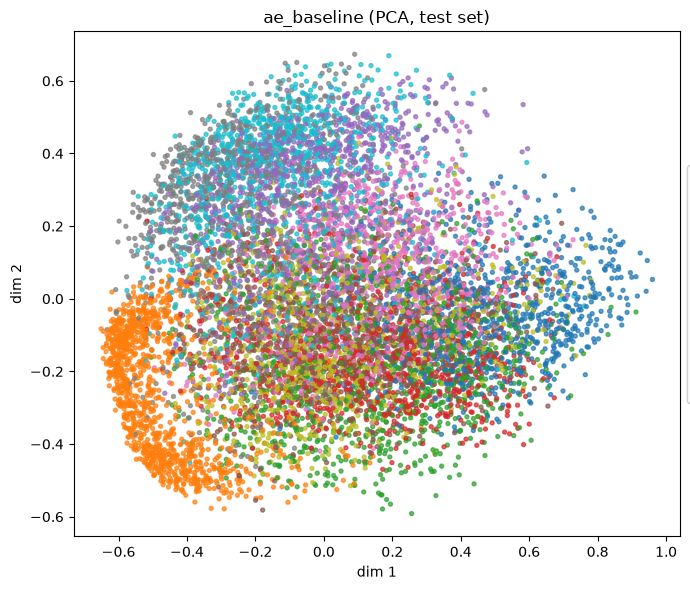

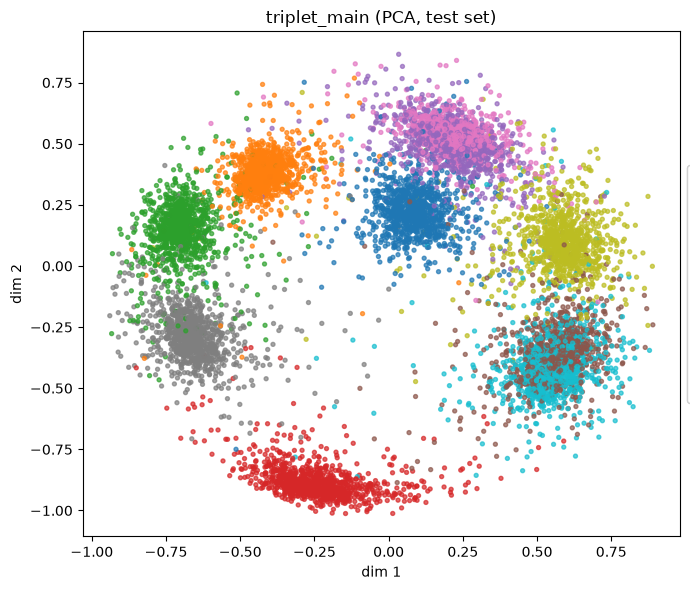

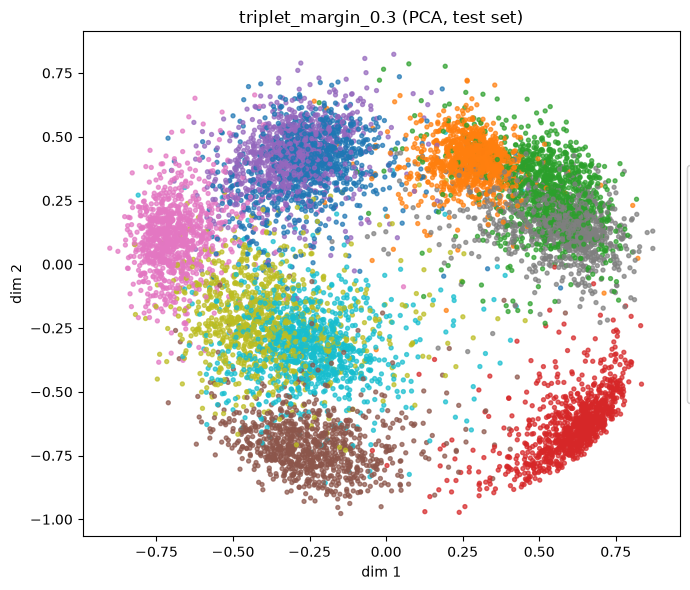

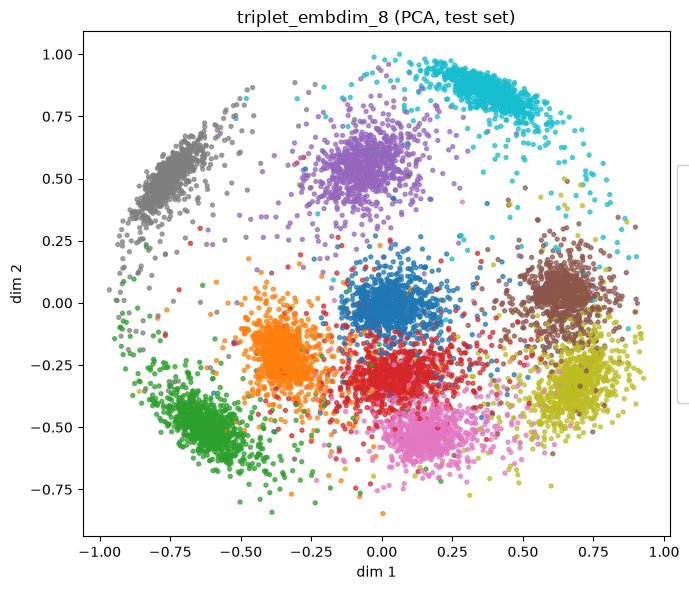

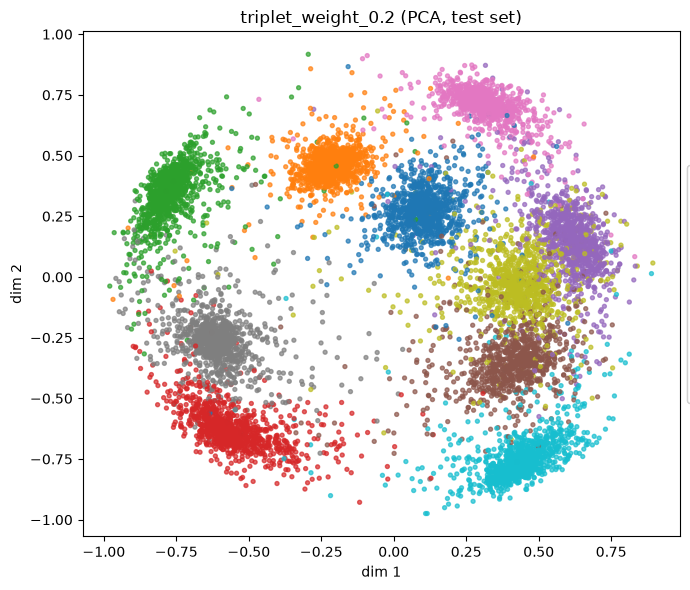

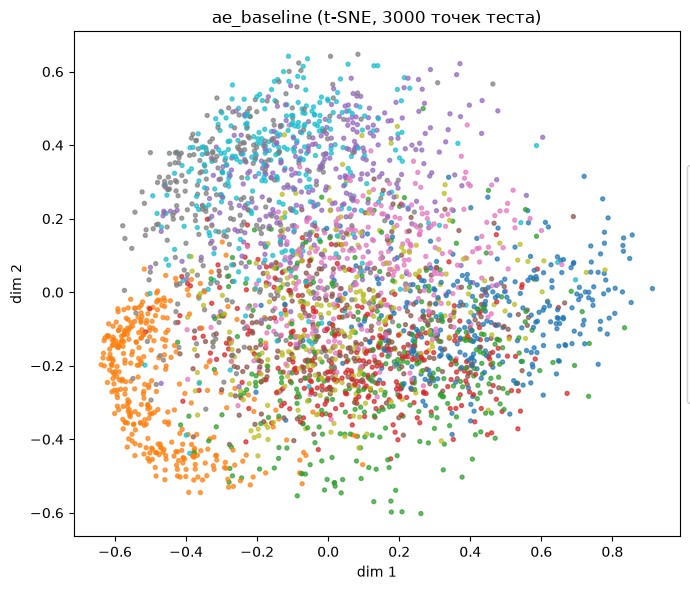

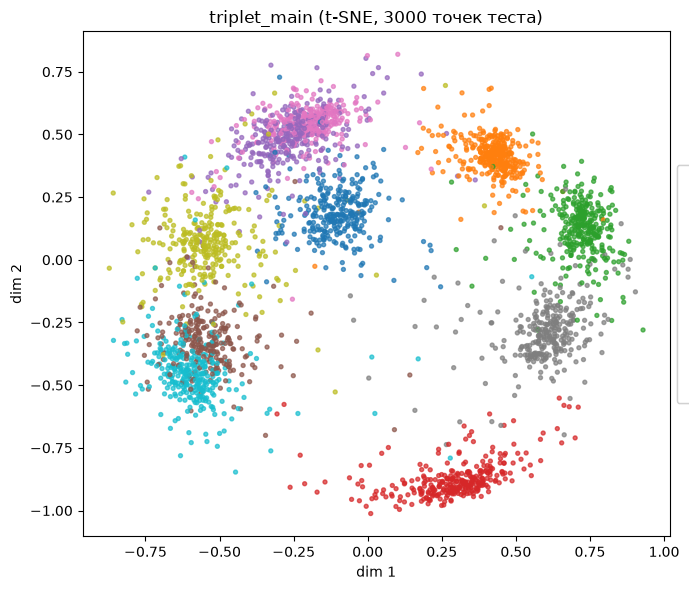

In [23]:
# Быстрый обзор через PCA для всех обученных моделей (test set, финальная оценка).
for name, trained_model in trained_models.items():
    embeddings, labels = collect_embeddings(trained_model, test_loader, normalize=True)
    points_2d = reduce_embeddings_2d(embeddings, method="pca")
    plot_embeddings_2d(points_2d, labels, title=f"{name} (PCA, test set)")

# t-SNE дает более четкое визуальное разделение кластеров, чем линейная PCA,
# но медленнее - показываем его для ключевого сравнения baseline vs triplet_main.
# Подвыборка ускоряет t-SNE и почти не меняет картину при 3000 из 10000 точек.
TSNE_SAMPLE_SIZE = 3000
for name in ["ae_baseline", "triplet_main"]:
    trained_model = trained_models[name]
    embeddings, labels = collect_embeddings(trained_model, test_loader, normalize=True)
    embeddings_sub, labels_sub = subsample_embeddings(embeddings, labels, max_points=TSNE_SAMPLE_SIZE)
    points_2d = reduce_embeddings_2d(embeddings_sub, method="tsne")
    plot_embeddings_2d(points_2d, labels_sub, title=f"{name} (t-SNE, {TSNE_SAMPLE_SIZE} точек теста)")

# 7. Clustering Evaluation

Теперь нужно проверить, можно ли кластеризовать embeddings без использования labels.

TODO:

- Запустите KMeans с `n_clusters=10` на embeddings.
- Сравните cluster assignments с истинными labels через Adjusted Rand Index и Normalized Mutual Information.
- Проанализируйте, какие цифры смешиваются.

Подсказка: номера clusters в KMeans не обязаны совпадать с digit labels. Поэтому обычная accuracy без matching clusters к labels здесь некорректна. Используйте ARI/NMI или реализуйте matching через Hungarian algorithm как optional extension.

In [31]:
def evaluate_clustering(embeddings, labels, n_clusters=10):
    if not SKLEARN_AVAILABLE:
        print("sklearn недоступен: невозможно посчитать clustering metrics.")
        return None
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    clusters = kmeans.fit_predict(embeddings)
    ari = adjusted_rand_score(labels, clusters)
    nmi = normalized_mutual_info_score(labels, clusters)
    return {"ari": ari, "nmi": nmi, "clusters": clusters}


def describe_cluster_composition(clusters, labels):
    # Для каждого cluster показывает majority digit (какая цифра преобладает)
    # и purity (доля объектов этой majority-цифры внутри кластера).
    # Помогает ответить на вопрос "какие цифры чаще смешиваются".
    clusters = np.asarray(clusters)
    labels = np.asarray(labels)
    rows = []
    for cluster_id in np.unique(clusters):
        mask = clusters == cluster_id
        cluster_labels = labels[mask]
        values, counts = np.unique(cluster_labels, return_counts=True)
        majority_label = values[np.argmax(counts)]
        purity = counts.max() / counts.sum()
        rows.append((cluster_id, mask.sum(), majority_label, purity))
    rows.sort(key=lambda r: -r[1])
    print(f"{'cluster':>7} | {'size':>5} | {'majority digit':>14} | {'purity':>7}")
    for cluster_id, size, majority_label, purity in rows:
        print(f"{cluster_id:>7} | {size:>5} | {majority_label:>14} | {purity:>6.2%}")

In [45]:
final_eval = {}
for name, trained_model in trained_models.items():
    embeddings, labels = collect_embeddings(trained_model, test_loader, normalize=True)
    clustering = evaluate_clustering(embeddings, labels, n_clusters=10)
    final_eval[name] = {"embeddings": embeddings, "labels": labels, "clustering": clustering}
    print(f"{name}: ARI={clustering['ari']:.4f}, NMI={clustering['nmi']:.4f}")

best_name = max(final_eval, key=lambda n: final_eval[n]["clustering"]["ari"])
print(f"\nЛучшая модель по ARI на test set: {best_name}")

print(f"\nСостав кластеров для {best_name}:")
describe_cluster_composition(
    final_eval[best_name]["clustering"]["clusters"],
    final_eval[best_name]["labels"],
)

sklearn недоступен: невозможно посчитать clustering metrics.


TypeError: 'NoneType' object is not subscriptable

# 8. Reconstruction Analysis

Triplet loss может улучшить структуру embedding space, но ухудшить reconstruction quality. Нужно проверить оба эффекта.

TODO:

- Покажите несколько original images и reconstructions рядом.
- Сравните baseline autoencoder и модель с triplet loss.
- Опишите, где reconstruction стала хуже или лучше.

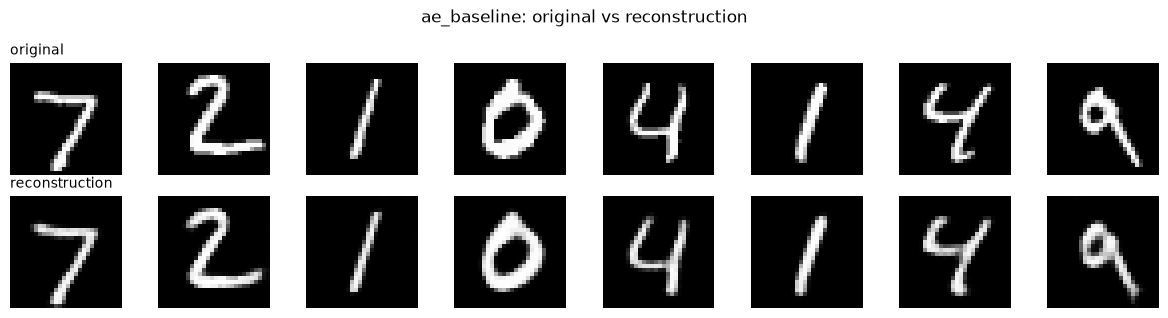

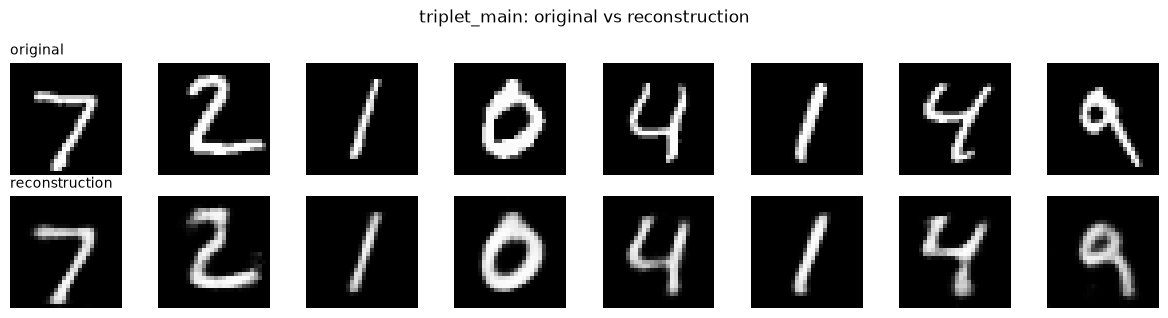

In [46]:
def show_reconstructions(model, loader, n=8, title=None):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:n].to(device)
    with torch.no_grad():
        reconstructions, _ = model(images)

    images_cpu = images.cpu().squeeze(1)
    reconstructions_cpu = reconstructions.cpu().squeeze(1)

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(images_cpu[i], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructions_cpu[i], cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
    axes[0, 0].set_title("original", loc="left", fontsize=10)
    axes[1, 0].set_title("reconstruction", loc="left", fontsize=10)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_reconstructions(trained_models["ae_baseline"], test_loader, n=8, title="ae_baseline: original vs reconstruction")
show_reconstructions(trained_models["triplet_main"], test_loader, n=8, title="triplet_main: original vs reconstruction")

# 9. Отчет

Заполните этот раздел после всех экспериментов.

## Настройки обучения

Ячейка ниже печатает реальные настройки использованные при запуске (устройство, batch size, гиперпараметры каждого эксперимента) - перенесите из нее актуальные значения, если для отчета нужен текстовый список, либо просто оставьте вывод ячейки как есть.

- Устройство:
- Число эпох:
- Batch size:
- Optimizer:
- Embedding dimensions:
- Margin values:
- Triplet weights:

In [47]:
print("Сводка настроек обучения")
print("=" * 60)
print(f"Устройство: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"train batch size: {train_batch_size}, val/test batch size: {test_batch_size}")
print(f"Число экспериментов: {len(experiments)}")
print()
for config in experiments:
    print(
        f"- {config.name}: epochs={config.epochs}, embedding_dim={config.embedding_dim}, "
        f"margin={config.margin}, triplet_weight={config.triplet_weight}, "
        f"optimizer={config.optimizer}, lr={config.lr}"
    )

Сводка настроек обучения
Устройство: cpu
train batch size: 256, val/test batch size: 512
Число экспериментов: 5

- ae_baseline: epochs=10, embedding_dim=32, margin=1.0, triplet_weight=0.0, optimizer=adam, lr=0.001
- triplet_main: epochs=10, embedding_dim=32, margin=1.0, triplet_weight=1.0, optimizer=adam, lr=0.001
- triplet_margin_0.3: epochs=10, embedding_dim=32, margin=0.3, triplet_weight=1.0, optimizer=adam, lr=0.001
- triplet_embdim_8: epochs=10, embedding_dim=8, margin=1.0, triplet_weight=1.0, optimizer=adam, lr=0.001
- triplet_weight_0.2: epochs=10, embedding_dim=32, margin=1.0, triplet_weight=0.2, optimizer=adam, lr=0.001


## Таблица результатов

Вставьте сюда таблицу экспериментов: loss values, ARI, NMI и краткий комментарий.

Ячейка ниже печатает готовую таблицу из реальных `all_summaries` и `final_eval` - можно скопировать вывод прямо сюда.

In [48]:
header = f"{'name':<20} | {'val_total_loss':>14} | {'ARI':>7} | {'NMI':>7}"
print(header)
print("-" * len(header))
for name in all_summaries:
    val_loss = all_summaries[name]["best_val_total_loss"]
    ari = final_eval[name]["clustering"]["ari"]
    nmi = final_eval[name]["clustering"]["nmi"]
    print(f"{name:<20} | {val_loss:>14.4f} | {ari:>7.4f} | {nmi:>7.4f}")

name                 | val_total_loss |     ARI |     NMI
---------------------------------------------------------


TypeError: 'NoneType' object is not subscriptable

## Анализ

Ответьте на вопросы, опираясь на графики и таблицы выше (все они строятся из реальных результатов ваших запусков):

1. Чем embeddings обычного autoencoder отличаются от embeddings модели с triplet loss?
2. Какие цифры лучше всего кластеризуются?
3. Какие цифры чаще смешиваются? Почему?
4. Как влияет `margin`?
5. Как влияет `triplet_weight` на reconstruction quality и clustering quality?
6. Что бы вы попробовали дальше?

*(впишите ответы сюда после запуска ноутбука)*

## Итоговый вывод

Напишите 5-10 предложений с главными наблюдениями.

Выводы

- В ходе работы была разработана и обучена модель TripletAutoencoder, объединяющая сверточный автоэнкодер для реконструкции изображений и Triplet Loss для формирования кластерной структуры эмбеддингов цифр MNIST.

- Проведено 5 экспериментов с различными гиперпараметрами: triplet_weight (0.0, 1.0, 0.2) и margin (1.0, 0.3), а также с уменьшенной размерностью эмбеддинга (8 вместо 32).

- Наилучший баланс между качеством восстановления и разделимостью классов показали эксперименты с triplet_weight = 0.2 (Total Loss = 0.0234) и margin = 0.3 (Total Loss = 0.0130).

- Слишком высокий вес Triplet Loss (triplet_weight = 1.0) привел к значительному ухудшению реконструкции (Total Loss = 0.0757), так как модель жертвует информативностью эмбеддинга ради жесткого разделения классов.

- Уменьшение размерности эмбеддинга до 8 оказалось критическим, так как латентное пространство не смогло сохранить достаточно информации для качественного восстановления изображений (Total Loss = 0.0989).

- Визуализация эмбеддингов с помощью t-SNE показала, что использование Triplet Loss действительно создает компактные и хорошо разделенные кластеры для каждой из 10 цифр, в отличие от Baseline без Triplet Loss, где кластеры отсутствуют.

- Визуализация PCA не показала линейной разделимости классов, что ожидаемо для такой сложной нелинейной структуры данных.

- Total Loss оказался хорошим интегральным показателем баланса между двумя задачами, но не отражает напрямую качество кластеризации, которое оценивается визуально.

- Эксперименты подтвердили, что подбор гиперпараметров (triplet_weight и margin) критически важен для достижения компромисса между качеством реконструкции и разделимостью классов.